In [17]:
# Import required libraries

import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

# Machine Learning libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [3]:
import pyodbc

# SQL Server Connection
connection = pyodbc.connect(
    'DRIVER={SQL Server};'
    'SERVER=DILLIBABU\SQLEXPRESS;'
    'DATABASE=CFB;'
    'Trusted_Connection=yes;'
)

In [4]:
# SQL Query
query = "SELECT * FROM riser"

# Load data into DataFrame
df = pd.read_sql(query, connection)

# Display first 5 rows
print(df.head())

   Ug   Gs     z    r/R  Solid_holdup  Particle_velocity  Solid_flux
0   5  100  0.57  0.000         0.007               6.12       77.86
1   5  100  5.84  0.950         0.027              -0.04       -2.05
2   5  100  5.84  0.837         0.032               2.47      138.94
3   5  100  5.84  0.548         0.010               7.17      128.14
4   5  100  7.78  0.000         0.010               7.81      139.78


C:\Users\dilli\AppData\Local\Temp\ipykernel_3388\1996162766.py:5: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, connection)


In [5]:
# Independent Variables (X)

X = df[['Ug',
        'Gs',
        'z',
        'r/R',
        'Particle_velocity',
        'Solid_flux']]

# Dependent Variable (y)

y = df['Solid_holdup']

In [6]:
# 80% Training
# 20% Testing

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Size:", X_train.shape)
print("Testing Size:", X_test.shape)

Training Size: (960, 6)
Testing Size: (240, 6)


In [7]:
# Create Model

model = LinearRegression()

# Train Model

model.fit(X_train, y_train)

print("Model Training Completed")

Model Training Completed


In [8]:
# Predict on test data

y_pred = model.predict(X_test)

print(y_pred[:10])

[ 0.33131051  0.01668708 -0.00098423  0.1631264   0.03264871  0.34896741
 -0.03688036  0.22519562  0.22742089  0.0296416 ]


In [9]:
# Mean Absolute Error

mae = mean_absolute_error(y_test, y_pred)

# Mean Squared Error

mse = mean_squared_error(y_test, y_pred)

# Root Mean Squared Error

rmse = np.sqrt(mse)

# R2 Score

r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE : 0.05951841126273729
MSE : 0.006229392736882669
RMSE: 0.07892650211990057
R2 Score: 0.6793765629137791


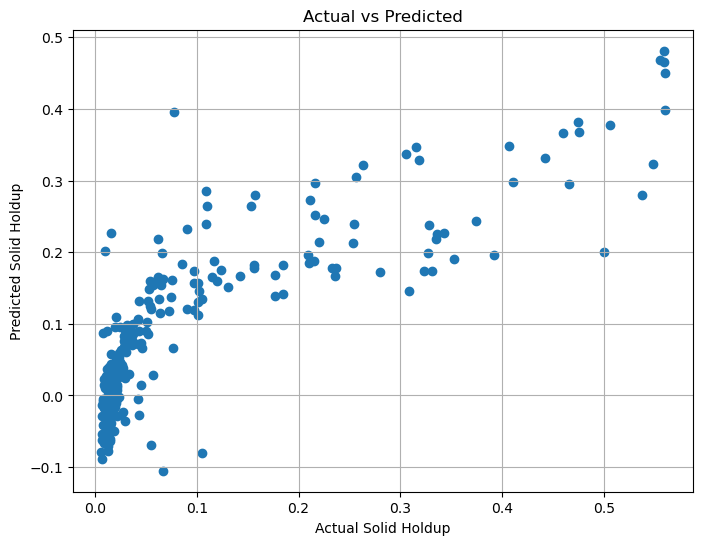

In [10]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Solid Holdup")
plt.ylabel("Predicted Solid Holdup")

plt.title("Actual vs Predicted")

plt.grid(True)

plt.show()

In [11]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

print(coefficients.sort_values(
    by='Coefficient',
    ascending=False
))

             Feature  Coefficient
3                r/R     0.044339
1                 Gs     0.000452
5         Solid_flux    -0.000117
2                  z    -0.001951
0                 Ug    -0.004291
4  Particle_velocity    -0.009442


In [12]:
import joblib

joblib.dump(model, "solid_holdup_model.pkl")

print("Model Saved Successfully")

Model Saved Successfully


In [13]:
import joblib

loaded_model = joblib.load("solid_holdup_model.pkl")

print("Model Loaded Successfully")

Model Loaded Successfully


In [14]:
new_data = pd.DataFrame({

    'Ug':[5],
    'Gs':[100],
    'z':[3],
    'r/R':[0.5],
    'Particle_velocity':[2.5],
    'Solid_flux':[250]

})

prediction = loaded_model.predict(new_data)

print("Predicted Solid Holdup:", prediction[0])

Predicted Solid Holdup: 0.03587810667069241
